# GRU with SHAP-Selected Union Features

This notebook is a variant of the original temporal forecasting model with one key change: instead of using all 49 sensor + time features, the input is restricted to the **union of the top-X sensor and top-Y demographic features** ranked by CatBoost SHAP importance for SIS and OHS separately.

Everything else mirrors the accepted paper:
- **FeatureGate**: SHAP-initialized learnable gates, one for SIS and one for OHS, applied to the union feature set
- **GRU + DecayAttention**: shared encoder with two target-specific recency-biased attention streams
- **18-item multi-task output**: 6 SIS items (1–5 scale) + 12 OHS items (0–4 scale)
- **Patient-grouped 5-fold CV**, leakage-safe temporal splits, same metrics

Demographic features are static per patient and are repeated at every time-step so the GRU sees patient context at each day.

In [20]:
from pathlib import Path
import copy
import math
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
from torch.utils.data import Dataset, DataLoader

# ============================================================
# KEY PARAMETERS — adjust these to change the feature budget
# TOP_X_SENSOR : top-X features taken from each target's sensor SHAP CSV
# TOP_Y_DEMO   : top-Y features taken from each target's demographic SHAP CSV
# The union of SIS and OHS selections forms the shared model input.
# ============================================================
TOP_X_SENSOR = 8
TOP_Y_DEMO   = 2

# Training hyperparameters — identical to the accepted paper
SEED         = 42
FORECAST_GAP = 7      # days between last sensor day and clinical assessment
BATCH_SIZE   = 12
N_FOLDS      = 5
MAX_EPOCHS   = 300
PATIENCE     = 45
LR           = 2e-3
WEIGHT_DECAY = 1e-3
HIDDEN_DIM   = 48
DROPOUT      = 0.15
DECAY_RATE   = 0.08

DEVICE   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_DIR = Path.cwd()
SHAP_DIR = DATA_DIR / "catboost-shap"

# Target item columns — same as the accepted paper
sis_targets = [f"sis-{i:02d}" for i in range(1, 7)]    # 6 items, scale 1–5
ohs_targets = [f"ohs-{i:02d}" for i in range(1, 13)]   # 12 items, scale 0–4

def seed_everything(seed: int) -> None:
    """Set all relevant random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)
plt.style.use("ggplot")
print(f"Device: {DEVICE}")
print(f"TOP_X_SENSOR={TOP_X_SENSOR}, TOP_Y_DEMO={TOP_Y_DEMO}")

Device: cpu
TOP_X_SENSOR=8, TOP_Y_DEMO=2


In [21]:
def ordered_union(a, b):
    seen = set(a)
    return a + [x for x in b if x not in seen]

sis_s = pd.read_csv(SHAP_DIR/"shap_catboost_sis_feature_importance.csv")["feature"].iloc[:TOP_X_SENSOR].tolist()
ohs_s = pd.read_csv(SHAP_DIR/"shap_catboost_ohs_feature_importance.csv")["feature"].iloc[:TOP_X_SENSOR].tolist()

sis_d = pd.read_csv(SHAP_DIR/"shap_catboost_demo_sis_feature_importance.csv")["feature"].iloc[:TOP_Y_DEMO].tolist()
ohs_d = pd.read_csv(SHAP_DIR/"shap_catboost_demo_ohs_feature_importance.csv")["feature"].iloc[:TOP_Y_DEMO].tolist()

n_sensor = len(ordered_union(sis_s, ohs_s))
n_demo   = len(ordered_union(sis_d, ohs_d))
print(f"n_sensor={n_sensor}, n_demo={n_demo}, total={n_sensor + n_demo}")

n_sensor=12, n_demo=3, total=15


## Feature Selection from SHAP CSVs

Top-X sensor features and top-Y demographic features are loaded separately for SIS and OHS from the pre-computed CatBoost SHAP importance rankings (`catboost-shap/` folder). The **union** of the two target-specific lists forms a single shared input feature set used by both prediction heads. Union ordering is deterministic: SIS-ranked features appear first, followed by any OHS features not already in the SIS list.

Because the SHAP CSVs rank all 46 sensor (or all 7 demographic) features — not just the top-X — every feature in the union has a valid SHAP importance value for both targets. This allows the FeatureGate priors to be constructed without any floor-value fallbacks.

In [22]:
def load_ranked_features(csv_path: Path, n: int) -> list:
    """Return the names of the top-n features from a SHAP importance CSV."""
    return pd.read_csv(csv_path)["feature"].iloc[:n].tolist()

def ordered_union(list_a: list, list_b: list) -> list:
    """Return list_a + items in list_b not already in list_a, preserving order."""
    seen = set(list_a)
    return list_a + [x for x in list_b if x not in seen]

# --- sensor features ---
sis_sensor_top  = load_ranked_features(SHAP_DIR / "shap_catboost_sis_feature_importance.csv", TOP_X_SENSOR)
ohs_sensor_top  = load_ranked_features(SHAP_DIR / "shap_catboost_ohs_feature_importance.csv", TOP_X_SENSOR)
union_sensor    = ordered_union(sis_sensor_top, ohs_sensor_top)

# --- demographic features ---
sis_demo_top    = load_ranked_features(SHAP_DIR / "shap_catboost_demo_sis_feature_importance.csv", TOP_Y_DEMO)
ohs_demo_top    = load_ranked_features(SHAP_DIR / "shap_catboost_demo_ohs_feature_importance.csv", TOP_Y_DEMO)
union_demo      = ordered_union(sis_demo_top, ohs_demo_top)

# Combined input feature list (sensor first, then demo)
input_cols  = union_sensor + union_demo
n_features  = len(input_cols)

print(f"Union sensor features ({len(union_sensor)}): {union_sensor}")
print(f"Union demo   features ({len(union_demo)}): {union_demo}")
print(f"Total input features per time-step: {n_features}")

Union sensor features (12): ['acceleration-movement-events-00to06', 'acceleration-mean', 'sleep-snoring', 'acceleration-minutes-with-data', 'acceleration-hours-with-data', 'sleep-heartrate-mean', 'step-count', 'sleep-deep', 'motion-mean', 'heartrate-mean', 'sleep-heartrate-min', 'acceleration-movement-events-12to18']
Union demo   features (3): ['relationship', 'age', 'fracture-type']
Total input features per time-step: 15


## SHAP Priors for FeatureGate Initialization

Each FeatureGate is initialized from the SHAP importance values of the corresponding target. For a given target, the prior vector is built by reading the SHAP weight for every feature in the union set from that target's full ranking CSV, then normalizing by the mean so the gate starts near 1.0 on average. This ensures the SIS gate emphasizes features ranked highly for SIS, while the OHS gate emphasizes features ranked highly for OHS.

In [23]:
def build_gate_prior(
    sensor_csv:  Path,
    demo_csv:    Path,
    sensor_cols: list,
    demo_cols:   list,
    floor:       float = 0.02,
) -> np.ndarray:
    """Build a normalized SHAP prior vector for FeatureGate initialization.

    Reads SHAP weights for every feature in sensor_cols and demo_cols from
    the provided CSVs (which rank all features, so no floor fallback is needed
    in practice). The combined vector is normalized by its mean so that the
    average gate weight starts at 1.0.
    """
    # Load sensor SHAP weights
    sensor_shap = pd.read_csv(sensor_csv).set_index("feature")["weights"].to_dict()
    sensor_prior = np.array([sensor_shap.get(c, floor) for c in sensor_cols], dtype=np.float32)

    # Load demographic SHAP weights
    demo_shap = pd.read_csv(demo_csv).set_index("feature")["weights"].to_dict()
    demo_prior = np.array([demo_shap.get(c, floor) for c in demo_cols], dtype=np.float32)

    # Concatenate and normalize so the mean gate weight starts at 1.0
    combined = np.concatenate([sensor_prior, demo_prior])
    return (combined / combined.mean()).astype(np.float32)


# Build priors for SIS and OHS gates over the shared union feature set
sis_prior = build_gate_prior(
    SHAP_DIR / "shap_catboost_sis_feature_importance.csv",
    SHAP_DIR / "shap_catboost_demo_sis_feature_importance.csv",
    union_sensor, union_demo,
)
ohs_prior = build_gate_prior(
    SHAP_DIR / "shap_catboost_ohs_feature_importance.csv",
    SHAP_DIR / "shap_catboost_demo_ohs_feature_importance.csv",
    union_sensor, union_demo,
)

# Display initial gate priorities
prior_df = pd.DataFrame({
    "feature"  : input_cols,
    "SIS prior": sis_prior.round(3),
    "OHS prior": ohs_prior.round(3),
}).sort_values("SIS prior", ascending=False)
display(prior_df.head(10))

,feature,SIS prior,OHS prior
12,relationship,2.423,1.333
13,age,2.216,2.613
14,fracture-type,1.899,1.840
0,acceleration-movement-events-00to06,1.136,1.153
1,acceleration-mean,1.054,2.354
2,sleep-snoring,0.996,0.700
3,acceleration-minutes-with-data,0.833,0.208
4,acceleration-hours-with-data,0.823,0.261
5,sleep-heartrate-mean,0.746,0.421
6,step-count,0.672,0.138


## Data Loading

Two CSV files are combined:
- `data/maison-llf-features.csv` — 1008 rows of daily sensor readings with clinical outcomes
- `data/maison-llf-demographics.csv` — 18 rows (one per patient); categorical columns are label-encoded to integers

In [24]:
# ── Sensor / clinical data ────────────────────────────────────────────────────
raw = pd.read_csv(
    DATA_DIR / "data" / "maison-llf-features.csv",
    parse_dates=["timestamp", "clinical-timestamp"]
).sort_values(["participant", "timestamp", "clinical-timestamp"]).reset_index(drop=True)

# Identify all 46 sensor columns (exclude IDs and clinical outcome columns)
id_cols       = ["participant", "timestamp", "clinical-timestamp"]
clinical_cols = (
    ["sis", "ohs", "oks", "tug", "chairstand"]
    + [f"sis-{i:02d}" for i in range(1, 7)]
    + [f"ohs-{i:02d}" for i in range(1, 13)]
    + [f"oks-{i:02d}" for i in range(1, 13)]
)
sensor_cols_all = [c for c in raw.columns if c not in id_cols + clinical_cols]

print(f"Features CSV: {len(raw)} rows, {raw['participant'].nunique()} patients")
print(f"All sensor columns ({len(sensor_cols_all)}): {sensor_cols_all}")

# ── Demographics ──────────────────────────────────────────────────────────────
demo_raw = pd.read_csv(DATA_DIR / "data" / "maison-llf-demographics.csv")

# Label-encode categorical columns (pandas >= 2.0 uses StringDtype, not object)
demo_encoded = demo_raw.copy()
label_maps   = {}
for col in [c for c in demo_raw.columns if c != "participant" and not pd.api.types.is_numeric_dtype(demo_raw[c])]:
    cats = sorted(demo_raw[col].dropna().unique())
    mapping = {c: float(i) for i, c in enumerate(cats)}
    demo_encoded[col] = demo_raw[col].map(mapping)
    label_maps[col] = mapping
for col in [c for c in demo_raw.columns if c != "participant" and pd.api.types.is_numeric_dtype(demo_raw[c])]:
    demo_encoded[col] = demo_raw[col].astype(float)

# Index by participant for O(1) lookup
demo_lookup = demo_encoded.set_index("participant").astype(float)
print(f"\nDemographic columns: {demo_lookup.columns.tolist()}")
print("Label maps:", {k: v for k, v in label_maps.items()})

Features CSV: 1008 rows, 18 patients
All sensor columns (46): ['acceleration-count', 'acceleration-mean', 'acceleration-std', 'acceleration-sum', 'acceleration-entropy', 'acceleration-kurtosis', 'acceleration-skew', 'acceleration-coefficient-of-variation', 'acceleration-minutes-with-data', 'acceleration-hours-with-data', 'acceleration-movement-events-00to06', 'acceleration-movement-events-06to12', 'acceleration-movement-events-12to18', 'acceleration-movement-events-18to24', 'acceleration-movement-events-24h', 'acceleration-intradaily-variability', 'heartrate-count', 'heartrate-min', 'heartrate-max', 'heartrate-mean', 'heartrate-std', 'heartrate-hours-with-data', 'motion-count', 'motion-ratio', 'motion-mean', 'motion-max', 'motion-max-timestamp', 'position-count', 'position-duration', 'position-distance-travelled', 'sleep-total', 'sleep-deep', 'sleep-light', 'sleep-rem', 'sleep-snoring', 'sleep-duration-to-sleep', 'sleep-duration-to-wakeup', 'sleep-wakeup-count', 'sleep-heartrate-mean',

## Build Temporal Examples

One example is generated per (patient, clinical assessment) pair. The sensor history window ends `FORECAST_GAP` days before the assessment timestamp, yielding expanding windows of 7, 21, 35, and 49 days for the four biweekly assessments.

Each example stores all 46 sensor columns (feature selection is applied later per fold inside the Dataset) and all demographic values for that patient.

In [25]:
def build_forecast_examples(features_df: pd.DataFrame, demo_lkp: pd.DataFrame, gap_days: int) -> list:
    """Build one example dict per (patient, clinical assessment) pair.

    Each dict contains:
        patient         : int
        clinical_time   : Timestamp — assessment date (prediction target)
        cutoff          : Timestamp — last allowed sensor date
        timestamps      : np.ndarray — dates in the sensor history window
        x_sensor_frame  : DataFrame (T, 46) — all sensor columns, unprocessed
        demo_values     : dict — all label-encoded demographics for this patient
        sis             : np.ndarray (6,) — SIS item scores at clinical_time
        ohs             : np.ndarray (12,) — OHS item scores at clinical_time
        sis_total       : float — SIS total score
        ohs_total       : float — OHS total score
    """
    examples = []
    for patient, pdf in features_df.groupby("participant", sort=True):
        pdf      = pdf.sort_values("timestamp")
        demo_row = demo_lkp.loc[patient].to_dict()   # static per patient

        for clinical_time, assess_rows in pdf.groupby("clinical-timestamp", sort=True):
            cutoff  = clinical_time - pd.Timedelta(days=gap_days)
            history = pdf.loc[pdf["timestamp"] <= cutoff].copy()
            if history.empty:
                continue
            tr = assess_rows.iloc[0]
            examples.append({
                "patient"      : int(patient),
                "clinical_time": clinical_time,
                "cutoff"       : cutoff,
                "timestamps"   : history["timestamp"].to_numpy(),
                # Store all sensor columns; union selection applied inside Dataset
                "x_sensor_frame": history[sensor_cols_all].copy(),
                # Static per patient — repeated across all T time-steps
                "demo_values"  : demo_row,
                "sis"          : tr[sis_targets].astype(float).to_numpy(),
                "ohs"          : tr[ohs_targets].astype(float).to_numpy(),
                "sis_total"    : float(tr["sis"]),
                "ohs_total"    : float(tr["ohs"]),
            })
    return examples


examples      = build_forecast_examples(raw, demo_lookup, FORECAST_GAP)
example_index = pd.DataFrame([{
    "patient"      : e["patient"],
    "clinical_time": e["clinical_time"],
    "history_days" : len(e["timestamps"]),
} for e in examples])

# Sanity checks
assert len(examples) == raw["participant"].nunique() * 4
assert example_index.groupby("patient")["history_days"].apply(list).eq(
    [[7, 21, 35, 49]] * raw["participant"].nunique()
).all(), "History window mismatch"

print(f"Total examples: {len(examples)} (18 patients × 4 assessments)")
print(example_index.head(8).to_string(index=False))

Total examples: 72 (18 patients × 4 assessments)
 patient clinical_time  history_days
       1    2022-04-13             7
       1    2022-04-27            21
       1    2022-05-11            35
       1    2022-05-25            49
       2    2022-10-28             7
       2    2022-11-11            21
       2    2022-11-25            35
       2    2022-12-09            49


## Patient-Grouped Cross-Validation

Patients are shuffled once (seed=2026) and split into 5 mutually exclusive folds. Each fold designates one group as test, the immediately following group as validation for early stopping, and the remaining patients as training. No patient appears in more than one partition.

In [26]:
all_patients = np.array(sorted(example_index["patient"].unique()))
rng          = np.random.default_rng(SEED)
shuffled     = all_patients.copy()
rng.shuffle(shuffled)
test_folds   = [np.array(f, dtype=int) for f in np.array_split(shuffled, N_FOLDS)]

def example_ids_for(patients) -> np.ndarray:
    """Return example indices whose patient is in the given set."""
    return np.flatnonzero(example_index["patient"].isin(patients).to_numpy())

def patients_of(ids) -> list:
    return sorted(example_index.iloc[ids]["patient"].unique().tolist())

cv_folds = []
for i, test_pts in enumerate(test_folds):
    val_pts   = test_folds[(i + 1) % N_FOLDS]
    train_pts = np.array(
        [p for p in all_patients if p not in set(test_pts) | set(val_pts)], dtype=int
    )
    assert set(patients_of(example_ids_for(train_pts))).isdisjoint(
        patients_of(example_ids_for(val_pts)) + patients_of(example_ids_for(test_pts))
    )
    cv_folds.append({
        "fold"          : i + 1,
        "train_ids"     : example_ids_for(train_pts),
        "val_ids"       : example_ids_for(val_pts),
        "test_ids"      : example_ids_for(test_pts),
        "train_patients": train_pts.tolist(),
    })

display(pd.DataFrame([{
    "fold"   : f["fold"],
    "train"  : patients_of(f["train_ids"]),
    "val"    : patients_of(f["val_ids"]),
    "test"   : patients_of(f["test_ids"]),
    "n_train": len(f["train_ids"]),
    "n_val"  : len(f["val_ids"]),
    "n_test" : len(f["test_ids"]),
} for f in cv_folds]))

,fold,train,val,test,n_train,n_val,n_test
0,1,"[1, 2, 3, 5, 6, 9, 12, 14, 15, 16]","[4, 8, 10, 11]","[7, 13, 17, 18]",40,16,16
1,2,"[2, 3, 5, 7, 9, 13, 14, 16, 17, 18]","[1, 6, 12, 15]","[4, 8, 10, 11]",40,16,16
2,3,"[2, 4, 7, 8, 9, 10, 11, 13, 14, 17, 18]","[3, 5, 16]","[1, 6, 12, 15]",44,12,16
3,4,"[1, 4, 6, 7, 8, 10, 11, 12, 13, 15, 17, 18]","[2, 9, 14]","[3, 5, 16]",48,12,12
4,5,"[1, 3, 4, 5, 6, 8, 10, 11, 12, 15, 16]","[7, 13, 17, 18]","[2, 9, 14]",44,16,12


## Normalization and Dataset

Two separate normalization routines, both fit on training data only:
- **Sensor stats** — median imputation then z-score from all daily training rows
- **Demo stats** — z-score from training patients' demographic values (one row per patient, so longer sensor histories do not over-weight a patient)

At inference time, demographic values are normalized and tiled across every time-step so each day's input vector is `[union_sensor_features | union_demo_features]` of dimension `n_features`.

In [27]:
def compute_sensor_stats(train_ids: np.ndarray) -> dict:
    """Median, mean, and std for union sensor features from training daily rows."""
    frames  = pd.concat(
        [examples[i]["x_sensor_frame"].reindex(columns=union_sensor) for i in train_ids],
        ignore_index=True
    )
    median  = frames.median(numeric_only=True)
    imputed = frames.fillna(median)
    mean    = imputed.mean()
    std     = imputed.std(ddof=0).replace(0, 1.0).fillna(1.0)
    return {"median": median, "mean": mean, "std": std}


def compute_demo_stats(train_patients: list) -> dict:
    """Mean and std for union demo features from training patients (one row each)."""
    dt   = demo_lookup.loc[demo_lookup.index.isin(train_patients), union_demo]
    mean = dt.mean()
    std  = dt.std(ddof=0).replace(0, 1.0).fillna(1.0)
    return {"mean": mean, "std": std}


def transform_inputs(example: dict, sensor_stats: dict, demo_stats: dict) -> np.ndarray:
    """Build input tensor of shape (T, n_features) for one example.

    Sensor features (T × X): normalized daily readings.
    Demo features (1 × Y):   normalized static values, tiled to (T × Y).
    Output: concatenation of both, shape (T, X+Y).
    """
    T = len(example["timestamps"])

    # Sensor: (T, len(union_sensor))
    s_df   = example["x_sensor_frame"].reindex(columns=union_sensor).fillna(sensor_stats["median"])
    s_norm = ((s_df - sensor_stats["mean"]) / sensor_stats["std"]).astype(np.float32).to_numpy()

    # Demo: (1, len(union_demo)) → tile to (T, len(union_demo))
    d_vals = np.array([example["demo_values"][c] for c in union_demo], dtype=np.float32)
    d_norm = ((d_vals - demo_stats["mean"].to_numpy()) / demo_stats["std"].to_numpy()).astype(np.float32)
    d_tiled = np.tile(d_norm, (T, 1))

    return np.concatenate([s_norm, d_tiled], axis=1)   # (T, n_features)


class ForecastDataset(Dataset):
    """Wraps examples for one fold with per-fold normalization statistics."""
    def __init__(self, records: list, ids: np.ndarray, sensor_stats: dict, demo_stats: dict):
        self.records      = [records[i] for i in ids]
        self.sensor_stats = sensor_stats
        self.demo_stats   = demo_stats

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        e = self.records[idx]
        x = transform_inputs(e, self.sensor_stats, self.demo_stats)
        return {
            "x"           : torch.tensor(x.tolist(), dtype=torch.float32),
            "sis"         : torch.tensor(e["sis"].tolist(), dtype=torch.float32),
            "ohs"         : torch.tensor(e["ohs"].tolist(), dtype=torch.float32),
            "patient"     : e["patient"],
            "clinical_time": e["clinical_time"],
        }


def collate_fn(batch: list) -> dict:
    """Pad variable-length sequences within a batch.

    Returns padded x of shape (B, T_max, n_features), a bool mask,
    per-example lengths, and item-level SIS / OHS targets.
    """
    lengths = torch.tensor([len(b["x"]) for b in batch], dtype=torch.long)
    max_len = int(lengths.max())
    x    = torch.zeros(len(batch), max_len, n_features, dtype=torch.float32)
    mask = torch.zeros(len(batch), max_len, dtype=torch.bool)
    for i, b in enumerate(batch):
        L = int(lengths[i])
        x[i, :L]    = b["x"]
        mask[i, :L] = True
    return {
        "x"           : x,
        "mask"        : mask,
        "lengths"     : lengths,
        "sis"         : torch.stack([b["sis"] for b in batch]),
        "ohs"         : torch.stack([b["ohs"] for b in batch]),
        "patient"     : [b["patient"]      for b in batch],
        "clinical_time": [b["clinical_time"] for b in batch],
    }


def make_loader(ids: np.ndarray, sensor_stats: dict, demo_stats: dict, shuffle: bool) -> DataLoader:
    return DataLoader(
        ForecastDataset(examples, ids, sensor_stats, demo_stats),
        batch_size=BATCH_SIZE, shuffle=shuffle, collate_fn=collate_fn
    )


# Smoke-test: verify shape for fold 0
_ss = compute_sensor_stats(cv_folds[0]["train_ids"])
_ds = compute_demo_stats(cv_folds[0]["train_patients"])
_ldr = make_loader(cv_folds[0]["train_ids"], _ss, _ds, shuffle=True)
_batch = next(iter(_ldr))
print({k: tuple(v.shape) for k, v in _batch.items() if torch.is_tensor(v)})
del _ss, _ds, _ldr, _batch

{'x': (12, 49, 15), 'mask': (12, 49), 'lengths': (12,), 'sis': (12, 6), 'ohs': (12, 12)}


## Model Architecture

The architecture mirrors the accepted paper with one modification: the input is the SHAP-selected union feature set instead of all 49 features.

- **FeatureGate**: two learnable gates (SIS, OHS), each initialized from the corresponding target's SHAP priors. Gate weights remain positive via softplus and are normalized at each forward pass.
- **Input projection**: gated SIS and OHS representations are concatenated → `Linear(n_features×2, hidden_dim)` → LayerNorm → GELU → Dropout
- **GRU**: single-layer, packed for variable-length efficiency
- **DecayAttention**: per-target attention with a learnable recency decay. Logits = `score(h_t) − λ·age_t` where `age_t` counts steps from the last valid observation
- **Prediction heads**: LayerNorm → Dropout → Linear; SIS head outputs 6 item scores, OHS head outputs 12 item scores

In [28]:
def inverse_softplus(x: np.ndarray) -> torch.Tensor:
    """Inverse of softplus — used to initialise learnable parameters from positive priors."""
    t = torch.tensor(np.asarray(x).tolist(), dtype=torch.float32).clamp_min(1e-4)
    return torch.log(torch.expm1(t))


class FeatureGate(nn.Module):
    """Learnable per-feature scaling initialised from SHAP importance priors.

    Gate weights are always positive (softplus) and normalized to mean=1 so
    the gate acts as a multiplicative attention over input features rather
    than as a global scale factor.
    """
    def __init__(self, prior: np.ndarray):
        super().__init__()
        # Reparametrize: raw is unconstrained; actual weight = softplus(raw)
        self.raw = nn.Parameter(inverse_softplus(prior))

    def forward(self, x: torch.Tensor):
        weights = torch.nn.functional.softplus(self.raw)          # positive
        weights = weights / weights.mean().clamp_min(1e-6)        # normalize
        return x * weights, weights


class DecayAttention(nn.Module):
    """Recency-biased attention over a GRU sequence.

    Attention logit for step t:
        logit_t = score(h_t) − decay · age_t
    where age_t = (seq_len − 1 − t) so the most recent step has age = 0.
    The scalar decay is learned via softplus reparametrisation.
    """
    def __init__(self, hidden_dim: int, decay_rate: float):
        super().__init__()
        self.score = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1),
        )
        self.raw_decay = nn.Parameter(
            inverse_softplus(np.array([decay_rate], dtype=np.float32))
        )

    def forward(self, encoded: torch.Tensor, mask: torch.Tensor, lengths: torch.Tensor):
        steps  = torch.arange(encoded.size(1), device=encoded.device).unsqueeze(0)
        age    = (lengths.to(encoded.device).unsqueeze(1) - 1 - steps).clamp_min(0).float()
        decay  = torch.nn.functional.softplus(self.raw_decay)
        logits = self.score(encoded).squeeze(-1) - decay * age
        logits = logits.masked_fill(~mask, -torch.finfo(encoded.dtype).max)
        attn   = torch.softmax(logits, dim=1)
        ctx    = torch.bmm(attn.unsqueeze(1), encoded).squeeze(1)
        return ctx, attn, decay


class MaisonTemporalForecaster(nn.Module):
    """Multi-task GRU forecaster with SHAP-guided feature gating.

    Input : (B, T, n_features)  where n_features = len(union_sensor) + len(union_demo)
    Output: dict with 'sis' (B, 6) and 'ohs' (B, 12) item predictions
    """
    def __init__(
        self,
        n_features: int,
        sis_prior:  np.ndarray,
        ohs_prior:  np.ndarray,
        hidden_dim: int,
        dropout:    float,
        decay_rate: float,
    ):
        super().__init__()
        # SHAP-initialized learnable gates, one per prediction target
        self.sis_gate = FeatureGate(sis_prior)
        self.ohs_gate = FeatureGate(ohs_prior)

        # Project concatenated gated representations to hidden dimension
        self.input_projection = nn.Sequential(
            nn.Linear(n_features * 2, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        # Shared GRU encoder
        self.gru = nn.GRU(hidden_dim, hidden_dim, batch_first=True)

        # Target-specific recency-biased attention
        self.sis_attention = DecayAttention(hidden_dim, decay_rate)
        self.ohs_attention = DecayAttention(hidden_dim, decay_rate)

        # Prediction heads
        self.sis_head = nn.Sequential(
            nn.LayerNorm(hidden_dim), nn.Dropout(dropout),
            nn.Linear(hidden_dim, len(sis_targets)),
        )
        self.ohs_head = nn.Sequential(
            nn.LayerNorm(hidden_dim), nn.Dropout(dropout),
            nn.Linear(hidden_dim, len(ohs_targets)),
        )

    def forward(self, x: torch.Tensor, mask: torch.Tensor, lengths: torch.Tensor) -> dict:
        # Apply target-specific feature gates
        sis_x, sis_w = self.sis_gate(x)   # (B, T, n_features)
        ohs_x, ohs_w = self.ohs_gate(x)

        # Concatenate gated representations and project to hidden_dim
        projected = self.input_projection(torch.cat([sis_x, ohs_x], dim=-1))

        # Encode with GRU (packed for efficiency with variable-length sequences)
        packed            = pack_padded_sequence(projected, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_enc, _     = self.gru(packed)
        encoded, _        = pad_packed_sequence(packed_enc, batch_first=True, total_length=x.size(1))

        # Target-specific recency-biased attention context vectors
        sis_ctx, sis_attn, sis_decay = self.sis_attention(encoded, mask, lengths)
        ohs_ctx, ohs_attn, ohs_decay = self.ohs_attention(encoded, mask, lengths)

        return {
            "sis"             : self.sis_head(sis_ctx),   # (B, 6)
            "ohs"             : self.ohs_head(ohs_ctx),   # (B, 12)
            "sis_attention"   : sis_attn,
            "ohs_attention"   : ohs_attn,
            "sis_gate_weights": sis_w,
            "ohs_gate_weights": ohs_w,
            "sis_decay"       : sis_decay,
            "ohs_decay"       : ohs_decay,
        }


def make_model() -> MaisonTemporalForecaster:
    return MaisonTemporalForecaster(
        n_features, sis_prior, ohs_prior, HIDDEN_DIM, DROPOUT, DECAY_RATE
    ).to(DEVICE)


# Parameter count
_m = make_model()
print(f"Trainable parameters: {sum(p.numel() for p in _m.parameters() if p.requires_grad):,}")
del _m

Trainable parameters: 21,604


## Training

Training uses **SmoothL1 (Huber) loss** summed across both tasks, **AdamW** optimizer with gradient clipping, and **early stopping** on validation loss (patience=45). The best checkpoint is restored after early stopping.

In [29]:
_loss_fn = nn.SmoothL1Loss()

def multitask_loss(output: dict, batch: dict) -> torch.Tensor:
    """Sum of SmoothL1 losses over SIS and OHS item predictions."""
    return _loss_fn(output["sis"], batch["sis"]) + _loss_fn(output["ohs"], batch["ohs"])


def move_batch(batch: dict) -> dict:
    """Move all tensor values in a batch dict to DEVICE."""
    return {k: v.to(DEVICE) if torch.is_tensor(v) else v for k, v in batch.items()}


def run_epoch(
    model:     MaisonTemporalForecaster,
    optimizer: torch.optim.Optimizer,
    loader:    DataLoader,
    training:  bool,
) -> float:
    """Run one training or validation epoch; return mean loss per example."""
    model.train(training)
    total, n = 0.0, 0
    for batch in loader:
        batch = move_batch(batch)
        with torch.set_grad_enabled(training):
            output = model(batch["x"], batch["mask"], batch["lengths"])
            loss   = multitask_loss(output, batch)
            if training:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
        total += loss.item() * len(batch["x"])
        n     += len(batch["x"])
    return total / n


def train_one_fold(fold: dict) -> dict:
    """Train a MaisonTemporalForecaster for one CV fold.

    Returns a dict with the trained model, normalization stats, fold metadata,
    training history, best validation loss, and learned decay values.
    """
    seed_everything(SEED + fold["fold"])

    # Compute fold-specific normalization stats from training data only
    sensor_stats = compute_sensor_stats(fold["train_ids"])
    demo_stats   = compute_demo_stats(fold["train_patients"])

    # Build loaders
    train_loader = make_loader(fold["train_ids"], sensor_stats, demo_stats, shuffle=True)
    val_loader   = make_loader(fold["val_ids"],   sensor_stats, demo_stats, shuffle=False)

    model     = make_model()
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    best_val   = float("inf")
    best_state = copy.deepcopy(model.state_dict())
    wait       = 0
    history    = []

    for epoch in range(1, MAX_EPOCHS + 1):
        train_loss = run_epoch(model, optimizer, train_loader, training=True)
        val_loss   = run_epoch(model, optimizer, val_loader,   training=False)
        history.append({"fold": fold["fold"], "epoch": epoch,
                        "train_loss": train_loss, "val_loss": val_loss})

        if val_loss < best_val - 1e-5:
            best_val   = val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait       = 0
        else:
            wait += 1
        if wait >= PATIENCE:
            break

    model.load_state_dict(best_state)

    # Extract learned decay values after training
    sis_decay = float(torch.nn.functional.softplus(model.sis_attention.raw_decay.detach()))
    ohs_decay = float(torch.nn.functional.softplus(model.ohs_attention.raw_decay.detach()))

    return {
        "fold"        : fold["fold"],
        "model"       : model,
        "sensor_stats": sensor_stats,
        "demo_stats"  : demo_stats,
        "train_ids"   : fold["train_ids"],
        "val_ids"     : fold["val_ids"],
        "test_ids"    : fold["test_ids"],
        "history"     : pd.DataFrame(history),
        "best_val"    : best_val,
        "epochs"      : len(history),
        "sis_decay"   : sis_decay,
        "ohs_decay"   : ohs_decay,
    }

## Cross-Validation Training Loop

In [30]:
cv_artifacts = []
for fold in cv_folds:
    artifact = train_one_fold(fold)
    cv_artifacts.append(artifact)
    print(
        f"Fold {artifact['fold']}: "
        f"epochs={artifact['epochs']:>3}, "
        f"best_val={artifact['best_val']:.4f}, "
        f"SIS decay={artifact['sis_decay']:.4f}, "
        f"OHS decay={artifact['ohs_decay']:.4f}"
    )

history_df = pd.concat([a["history"] for a in cv_artifacts], ignore_index=True)
display(pd.DataFrame([{
    "fold"     : a["fold"],
    "epochs"   : a["epochs"],
    "best_val" : round(a["best_val"],  4),
    "sis_decay": round(a["sis_decay"], 4),
    "ohs_decay": round(a["ohs_decay"], 4),
} for a in cv_artifacts]))

Fold 1: epochs= 52, best_val=1.5416, SIS decay=0.0771, OHS decay=0.0795
Fold 2: epochs= 58, best_val=0.9130, SIS decay=0.0796, OHS decay=0.0758
Fold 3: epochs= 55, best_val=1.0603, SIS decay=0.0788, OHS decay=0.0788
Fold 4: epochs= 52, best_val=1.2307, SIS decay=0.0808, OHS decay=0.0766
Fold 5: epochs= 55, best_val=0.9787, SIS decay=0.0757, OHS decay=0.0791


,fold,epochs,best_val,sis_decay,ohs_decay
0,1,52,1.5416,0.0771,0.0795
1,2,58,0.9130,0.0796,0.0758
2,3,55,1.0603,0.0788,0.0788
3,4,52,1.2307,0.0808,0.0766
4,5,55,0.9787,0.0757,0.0791


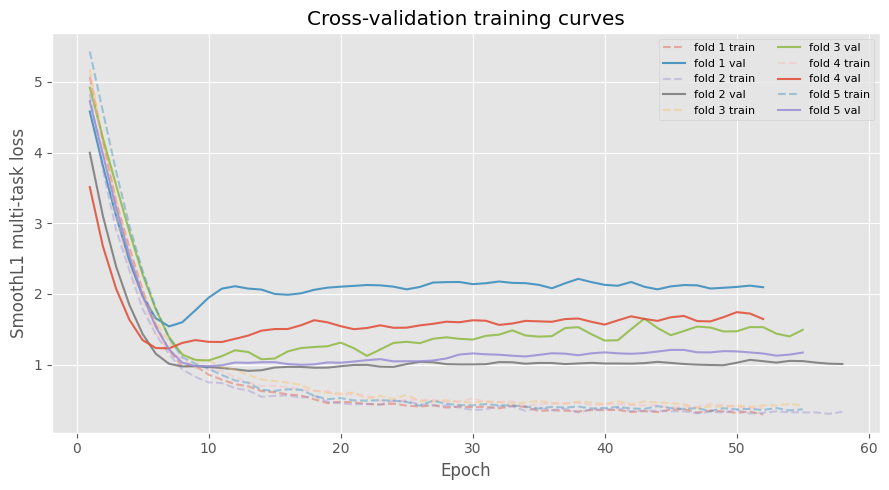

In [31]:
# Learning curves
fig, ax = plt.subplots(figsize=(9, 5))
for fold, fold_h in history_df.groupby("fold"):
    ax.plot(fold_h["epoch"], fold_h["train_loss"], linestyle="--", alpha=0.4, label=f"fold {fold} train")
    ax.plot(fold_h["epoch"], fold_h["val_loss"],   alpha=0.85,              label=f"fold {fold} val")
ax.set_xlabel("Epoch")
ax.set_ylabel("SmoothL1 multi-task loss")
ax.set_title("Cross-validation training curves")
ax.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

## Evaluation

Predictions are collected on held-out test patients for each fold. Per-item metrics (MAE, RMSE, R², Pearson r) are computed identically to the accepted paper. Total scores are reconstructed by summing per-item predictions.

In [32]:
def collect_predictions(artifact: dict) -> pd.DataFrame:
    """Run the model on its fold's test set and return a long-format DataFrame."""
    rows  = []
    model = artifact["model"]
    model.eval()
    loader = make_loader(
        artifact["test_ids"], artifact["sensor_stats"], artifact["demo_stats"], shuffle=False
    )
    with torch.no_grad():
        for batch in loader:
            dev_batch = move_batch(batch)
            output    = model(dev_batch["x"], dev_batch["mask"], dev_batch["lengths"])
            sis_pred  = output["sis"].cpu().tolist()
            ohs_pred  = output["ohs"].cpu().tolist()
            for i in range(len(batch["patient"])):
                base = {
                    "fold"         : artifact["fold"],
                    "patient"      : batch["patient"][i],
                    "clinical_time": pd.Timestamp(batch["clinical_time"][i]),
                    "history_days" : int(batch["lengths"][i]),
                }
                for name, truth, pred in zip(sis_targets, batch["sis"][i].tolist(), sis_pred[i]):
                    rows.append(base | {"outcome": "SIS", "item": name,
                                        "truth": float(truth), "prediction": float(pred)})
                for name, truth, pred in zip(ohs_targets, batch["ohs"][i].tolist(), ohs_pred[i]):
                    rows.append(base | {"outcome": "OHS", "item": name,
                                        "truth": float(truth), "prediction": float(pred)})
    return pd.DataFrame(rows)


def regression_metrics(frame: pd.DataFrame) -> pd.Series:
    """Compute MAE, RMSE, R², and Pearson r — identical to the accepted paper."""
    y, p     = frame["truth"].to_numpy(), frame["prediction"].to_numpy()
    pearson  = np.corrcoef(y, p)[0, 1] if (len(y) > 1 and np.std(y) > 0 and np.std(p) > 0) else np.nan
    residual = y - p
    sst      = np.square(y - y.mean()).sum()
    r2       = 1 - np.square(residual).sum() / sst if sst > 0 else np.nan
    return pd.Series({"n": len(frame), "MAE": np.abs(residual).mean(),
                      "RMSE": np.sqrt(np.square(residual).mean()), "R2": r2, "Pearson": pearson})


def grouped_metrics(frame: pd.DataFrame, group_cols: list) -> pd.DataFrame:
    rows = []
    for keys, group in frame.groupby(group_cols):
        keys = keys if isinstance(keys, tuple) else (keys,)
        rows.append(dict(zip(group_cols, keys)) | regression_metrics(group).to_dict())
    return pd.DataFrame(rows).set_index(group_cols)

In [33]:
# Collect all test predictions
cv_predictions = pd.concat(
    [collect_predictions(a) for a in cv_artifacts], ignore_index=True
)

print("=== Overall per-item metrics ===")
display(grouped_metrics(cv_predictions, ["outcome"]))

print("\n=== Per-fold metrics ===")
display(grouped_metrics(cv_predictions, ["fold", "outcome"]))

print("\n=== Per-item metrics ===")
display(grouped_metrics(cv_predictions, ["outcome", "item"]))

print("\n=== Per-patient metrics ===")
display(grouped_metrics(cv_predictions, ["patient", "outcome"]))

=== Overall per-item metrics ===


,n,MAE,RMSE,R2,Pearson
outcome,,,,,
OHS,864.0,1.180015,1.423412,-0.449271,-0.238125
SIS,432.0,1.063860,1.302951,-0.306724,-0.004317



=== Per-fold metrics ===


n       MAE      RMSE        R2   Pearson
fold outcome                                               
1    OHS      192.0  0.882544  1.052043 -0.307888 -0.094632
     SIS       96.0  1.102091  1.290605 -0.269180  0.262453
2    OHS      192.0  1.578335  1.845897 -0.750780 -0.414897
     SIS       96.0  1.304755  1.610600 -0.618045 -0.073660
3    OHS      192.0  0.941703  1.139542 -0.103605  0.041566
     SIS       96.0  0.899913  1.173711 -0.016082  0.219939
4    OHS      144.0  0.992280  1.166804  0.014843  0.293779
     SIS       72.0  1.044914  1.143002 -1.616947  0.454608
5    OHS      144.0  1.551033  1.744972 -1.627313 -0.469674
     SIS       72.0  0.929236  1.167583 -0.365621 -0.000115


=== Per-item metrics ===


n       MAE      RMSE        R2   Pearson
outcome item                                                
OHS     ohs-01  72.0  1.160385  1.353559 -0.523047 -0.391238
        ohs-02  72.0  1.095575  1.275554 -0.428860 -0.292931
        ohs-03  72.0  1.375605  1.508605 -0.463799 -0.277363
        ohs-04  72.0  1.292847  1.604170 -0.510623 -0.502142
        ohs-05  72.0  0.943227  1.142430 -0.395891 -0.170837
        ohs-06  72.0  0.905338  1.101635 -0.506897 -0.275965
        ohs-07  72.0  1.248649  1.421922 -0.408972 -0.334721
        ohs-08  72.0  1.057138  1.342617 -0.854123 -0.424888
        ohs-09  72.0  1.116345  1.366525 -0.530037 -0.347521
        ohs-10  72.0  1.054579  1.260078 -0.230916 -0.231773
        ohs-11  72.0  1.679147  2.031308 -0.624538 -0.387717
        ohs-12  72.0  1.231343  1.442279 -0.424894 -0.310642
SIS     sis-01  72.0  0.965432  1.111909 -0.468650 -0.083381
        sis-02  72.0  0.605239  0.748256 -0.295740 -0.062400
        sis-03  72.0  0.949189  1.169948 -0.436386 -0.142193
        sis-04  72.0  0.962191  1.218008 -0.852732 -0.473929
        sis-05  72.0  1.529327  1.770093 -0.407143 -0.301270
        sis-06  72.0  1.371783  1.550585 -0.361884 -0.350946


=== Per-patient metrics ===


n       MAE      RMSE        R2   Pearson
patient outcome                                              
1       OHS      48.0  0.903802  1.182150 -0.323928 -0.093572
        SIS      24.0  0.923766  1.136562  0.031170  0.301321
2       OHS      48.0  1.468181  1.635763 -3.673887 -0.218035
        SIS      24.0  1.133115  1.385633 -1.110512 -0.098664
3       OHS      48.0  0.925980  1.079916  0.250288  0.549007
        SIS      24.0  0.825523  0.965121 -0.344663  0.475045
4       OHS      48.0  2.435828  2.493640 -3.840145 -0.726492
        SIS      24.0  1.253546  1.643088 -3.331611 -0.444391
5       OHS      48.0  1.305635  1.454188 -1.604051 -0.200459
        SIS      24.0  1.137488  1.173628 -6.346150  0.828201
6       OHS      48.0  1.099273  1.318189 -0.374822  0.120245
        SIS      24.0  0.609087  0.743925  0.201071  0.519603
7       OHS      48.0  0.945375  1.124457 -0.663726  0.106519
        SIS      24.0  0.802307  1.018366  0.307819  0.613552
8       OHS      48.0  1.291495  1.699684 -1.049288 -0.669354
        SIS      24.0  1.145960  1.329298 -0.247318  0.453829
9       OHS      48.0  1.944269  2.056567 -1.605532 -0.666671
        SIS      24.0  1.091465  1.258918 -0.202751  0.122910
10      OHS      48.0  1.417263  1.699596 -0.670530  0.143827
        SIS      24.0  1.477415  1.796512 -1.074793  0.541923
11      OHS      48.0  1.168756  1.278101 -6.128188  0.269410
        SIS      24.0  1.342099  1.637653 -0.359840  0.437497
12      OHS      48.0  0.983081  1.104561 -0.047320  0.062917
        SIS      24.0  0.609868  0.767358 -2.140473 -0.026657
13      OHS      48.0  1.120477  1.298190 -0.427546 -0.254532
        SIS      24.0  1.218482  1.420115 -0.468564  0.346482
14      OHS      48.0  1.240648  1.493182 -1.170251 -0.411684
        SIS      24.0  0.563128  0.764784 -0.914201  0.154719
15      OHS      48.0  0.780656  0.916007  0.082915  0.384316
        SIS      24.0  1.456929  1.753954 -1.786132  0.385398
16      OHS      48.0  0.745225  0.896334  0.055096  0.283609
        SIS      24.0  1.171732  1.269055 -2.881375  0.206282
17      OHS      48.0  0.811732  0.939726 -0.518378 -0.251900
        SIS      24.0  1.081682  1.211714 -0.106953  0.264787
18      OHS      48.0  0.652592  0.770969 -0.269213  0.040449
        SIS      24.0  1.305893  1.463077 -7.622259 -0.259681

=== Total-score metrics ===


,n,MAE,RMSE,R2,Pearson
outcome,,,,,
OHS,72.0,7.637180,10.043426,-0.649628,-0.387948
SIS,72.0,4.760923,5.500884,-0.967224,-0.506169


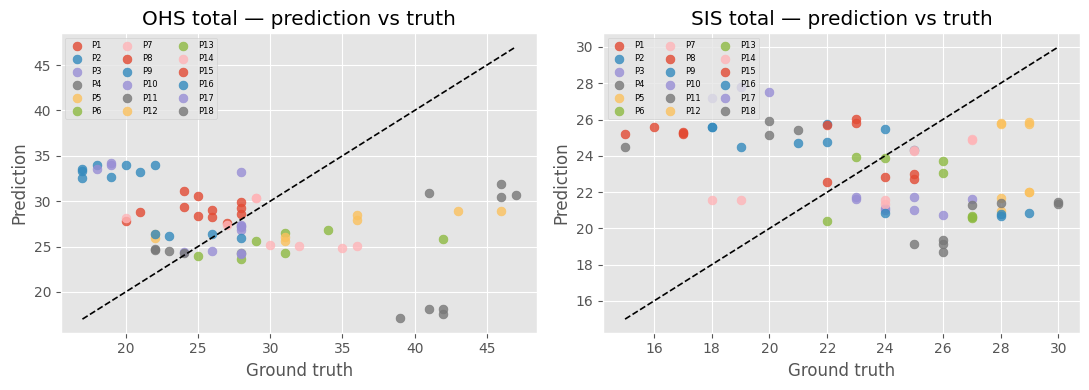

In [34]:
# Reconstruct total scores by summing per-item predictions, then plot
total_predictions = cv_predictions.groupby(
    ["fold", "patient", "clinical_time", "history_days", "outcome"], as_index=False
)[["truth", "prediction"]].sum()

print("=== Total-score metrics ===")
display(grouped_metrics(total_predictions, ["outcome"]))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (outcome, frame) in zip(axes, total_predictions.groupby("outcome")):
    for patient, pf in frame.groupby("patient"):
        ax.scatter(pf["truth"], pf["prediction"], label=f"P{patient}", alpha=0.8, s=40)
    lo = min(frame["truth"].min(), frame["prediction"].min())
    hi = max(frame["truth"].max(), frame["prediction"].max())
    ax.plot([lo, hi], [lo, hi], color="black", linewidth=1.2, linestyle="--")
    ax.set_title(f"{outcome} total — prediction vs truth")
    ax.set_xlabel("Ground truth")
    ax.set_ylabel("Prediction")
    ax.legend(fontsize=6, ncol=3, loc="upper left")
plt.tight_layout()
plt.show()

## Learned Feature Gate Weights

Inspecting the final gate weights shows which features the model emphasised for each target after training — useful for comparing with the initial SHAP priors.

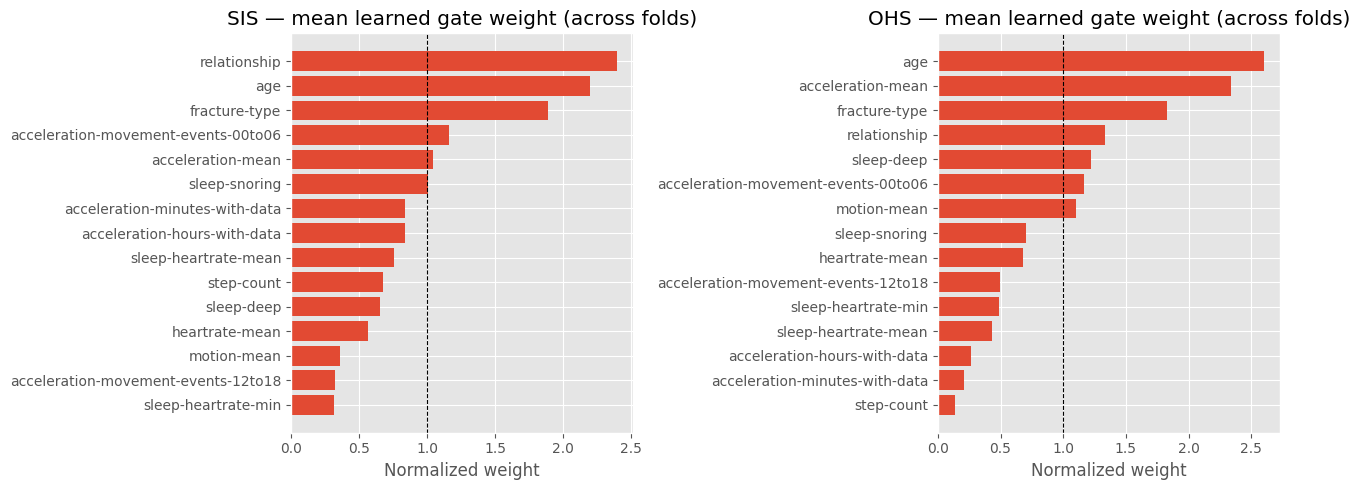

,SIS_learned,OHS_learned
feature,,
relationship,2.394,1.335
age,2.198,2.599
fracture-type,1.890,1.828
acceleration-movement-events-00to06,1.159,1.165
acceleration-mean,1.040,2.341
sleep-snoring,1.009,0.701
acceleration-minutes-with-data,0.836,0.209
acceleration-hours-with-data,0.835,0.265
sleep-heartrate-mean,0.752,0.428


In [35]:
weight_rows = []
for a in cv_artifacts:
    model = a["model"]
    with torch.no_grad():
        sis_w = torch.nn.functional.softplus(model.sis_gate.raw).cpu().numpy()
        ohs_w = torch.nn.functional.softplus(model.ohs_gate.raw).cpu().numpy()
    sis_w = sis_w / sis_w.mean()
    ohs_w = ohs_w / ohs_w.mean()
    for feat, sw, ow in zip(input_cols, sis_w, ohs_w):
        weight_rows.append({"fold": a["fold"], "feature": feat,
                             "SIS_learned": sw, "OHS_learned": ow})

learned_df = pd.DataFrame(weight_rows)
summary = learned_df.groupby("feature")[["SIS_learned", "OHS_learned"]].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, col, prior, label in zip(
    axes,
    ["SIS_learned", "OHS_learned"],
    [sis_prior, ohs_prior],
    ["SIS", "OHS"],
):
    s = summary[col].sort_values(ascending=False)
    ax.barh(s.index[::-1], s.values[::-1])
    ax.set_title(f"{label} — mean learned gate weight (across folds)")
    ax.set_xlabel("Normalized weight")
    ax.axvline(1.0, color="black", linestyle="--", linewidth=0.8)
plt.tight_layout()
plt.show()

display(summary.sort_values("SIS_learned", ascending=False).round(3))